(17996, 17)
             Artist Name                             Track Name  Popularity  \
0             Bruno Mars  That's What I Like (feat. Gucci Mane)        60.0   
1                 Boston                           Hitch a Ride        54.0   
2          The Raincoats                     No Side to Fall In        35.0   
3                   Deno             Lingo (feat. J.I & Chunkz)        66.0   
4  Red Hot Chili Peppers      Nobody Weird Like Me - Remastered        53.0   

   danceability  energy   key  loudness  mode  speechiness  acousticness  \
0         0.854   0.564   1.0    -4.964     1       0.0485      0.017100   
1         0.382   0.814   3.0    -7.230     1       0.0406      0.001100   
2         0.434   0.614   6.0    -8.334     1       0.0525      0.486000   
3         0.853   0.597  10.0    -6.528     0       0.0555      0.021200   
4         0.167   0.975   2.0    -4.279     1       0.2160      0.000169   

   instrumentalness  liveness  valence    tempo  duratio

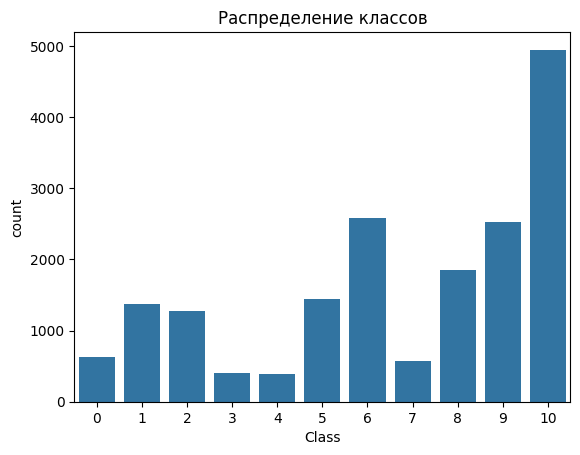

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
sns.countplot(x="Class", data=df)
plt.title("Распределение классов")
plt.show()

Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64
Class
10    4949
6     2587
9     2524
8     1854
5     1447
1     1373
2     1272
0      625
7      576
3      402
4      387
Name: count, dtype: int64


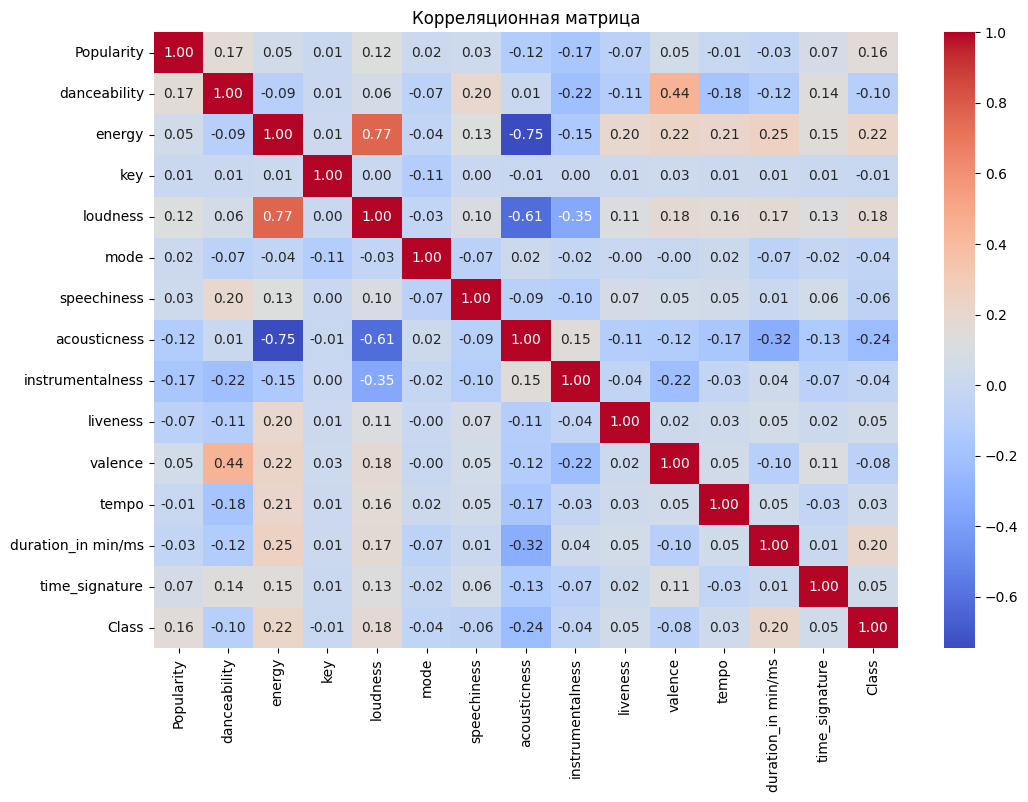

In [9]:
# удаляем столбцы
df = df.drop(columns=["Artist Name", "Track Name"])
# избавляемся от пропусков
df = df.fillna(df.median(numeric_only=True))
print(df.isnull().sum())
print(df["Class"].value_counts())
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

In [10]:
# X — признаки (всё кроме целевого столбца)
X = df.drop(columns=["Class"])
# y — целевая переменная (то что предсказываем)
y = df["Class"]
print(X.shape)
print(y.shape)

(17996, 14)
(17996,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}")
print(f"Test: {X_test.shape}")

Train : (14396, 14)
Test: (3600, 14)


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1 Дерево решений
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 2 Случайный лес
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3 Градиентный бустинг
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print(f"Дерево решений:    {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Случайный лес:     {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Градиентный бустинг: {accuracy_score(y_test, y_pred_gb):.4f}")

Дерево решений:    0.3606
Случайный лес:     0.4994
Градиентный бустинг: 0.5372


=== Дерево решений ===
              precision    recall  f1-score   support

           0       0.60      0.58      0.59       125
           1       0.08      0.12      0.09       275
           2       0.27      0.27      0.27       254
           3       0.59      0.60      0.60        80
           4       0.59      0.62      0.61        77
           5       0.51      0.54      0.53       290
           6       0.22      0.22      0.22       518
           7       0.91      0.90      0.91       115
           8       0.46      0.46      0.46       371
           9       0.37      0.36      0.36       505
          10       0.36      0.30      0.33       990

    accuracy                           0.36      3600
   macro avg       0.45      0.45      0.45      3600
weighted avg       0.37      0.36      0.37      3600

=== Случайный лес ===
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       125
           1       0.03      0.02

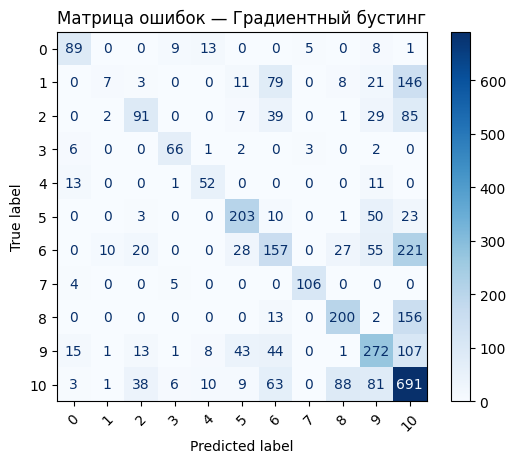

In [13]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
)

# Отчёт по каждому классу
print("=== Дерево решений ===")
print(classification_report(y_test, y_pred_dt))

print("=== Случайный лес ===")
print(classification_report(y_test, y_pred_rf))

print("=== Градиентный бустинг ===")
print(classification_report(y_test, y_pred_gb))

cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Матрица ошибок — Градиентный бустинг")
plt.show()

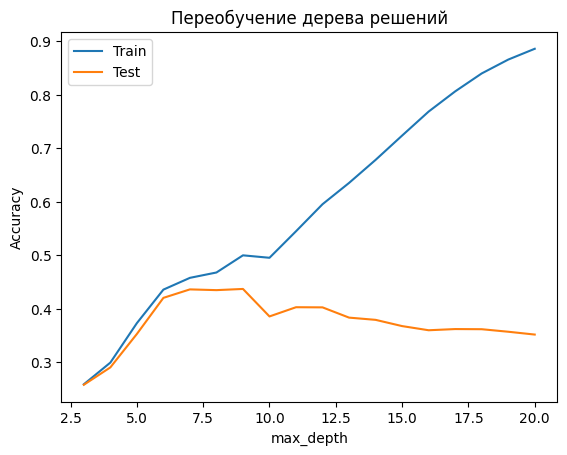

In [14]:
depths = range(3, 21)
train_scores = []
test_scores = []
for depth in depths:
    dt_tmp = DecisionTreeClassifier(
        max_depth=depth, random_state=42, class_weight="balanced"
    )
    dt_tmp.fit(X_train, y_train)
    train_scores.append(dt_tmp.score(X_train, y_train))
    test_scores.append(dt_tmp.score(X_test, y_test))
plt.plot(depths, train_scores, label="Train")
plt.plot(depths, test_scores, label="Test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Переобучение дерева решений")
plt.legend()
plt.show()

In [15]:
dt_best = DecisionTreeClassifier(max_depth=7, random_state=42, class_weight="balanced")
dt_best.fit(X_train, y_train)
y_pred_dt_best = dt_best.predict(X_test)

print("=== Улучшенное дерево ===")
print(classification_report(y_test, y_pred_dt_best))

=== Улучшенное дерево ===
              precision    recall  f1-score   support

           0       0.63      0.58      0.60       125
           1       0.19      0.07      0.10       275
           2       0.28      0.52      0.37       254
           3       0.58      0.76      0.66        80
           4       0.41      0.84      0.55        77
           5       0.57      0.73      0.64       290
           6       0.36      0.33      0.34       518
           7       0.93      0.91      0.92       115
           8       0.46      0.65      0.54       371
           9       0.33      0.25      0.28       505
          10       0.46      0.37      0.41       990

    accuracy                           0.44      3600
   macro avg       0.47      0.55      0.49      3600
weighted avg       0.43      0.44      0.42      3600



In [16]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=15,  # сколько случайных комбинаций попробовать
    cv=3,  # кросс-валидация на 3 фолда
    scoring="f1_macro",  # оптимизируем macro F1, не accuracy
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Лучшие параметры:", search.best_params_)
print("Лучший macro F1 на CV:", search.best_score_)

y_pred_rf_tuned = search.best_estimator_.predict(X_test)
print("=== Исходный лес ===")
print(f"macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print("=== Лес после подбора параметров ===")
print(classification_report(y_test, y_pred_rf_tuned))

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Лучшие параметры: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Лучший macro F1 на CV: 0.5720419178182917
=== Исходный лес ===
macro F1: 0.5634
=== Лес после подбора параметров ===
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       125
           1       0.04      0.03      0.04       275
           2       0.47      0.37      0.41       254
           3       0.76      0.78      0.77        80
           4       0.74      0.77      0.75        77
           5       0.68      0.70      0.69       290
           6       0.31      0.28      0.29       518
           7       0.94      0.92      0.93       115
           8       0.60      0.49      0.54       371
           9       0.52      0.53      0.53       505
          10       0.47      0.59      0.53       990

    accuracy                           0.50      3600
   macro avg       0.57      0.56      0.56      3600
weighted avg       0.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
}

search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    verbose=1,
)

search_gb.fit(X_train, y_train)

print("Лучшие параметры:", search_gb.best_params_)
y_pred_gb_tuned = search_gb.best_estimator_.predict(X_test)

print("=== Исходный GB ===")
print(f"macro F1: {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
print("=== GB после подбора ===")
print(classification_report(y_test, y_pred_gb_tuned))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
=== Исходный GB ===
macro F1: 0.5663
=== GB после подбора ===
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       125
           1       0.22      0.02      0.04       275
           2       0.53      0.35      0.42       254
           3       0.78      0.78      0.78        80
           4       0.71      0.74      0.73        77
           5       0.66      0.70      0.68       290
           6       0.38      0.31      0.34       518
           7       0.91      0.93      0.92       115
           8       0.59      0.53      0.56       371
           9       0.55      0.55      0.55       505
          10       0.48      0.70      0.57       990

    accuracy                           0.54      3600
   macro avg       0.59      0.58      0.57      3600
weighted avg       0.5

In [18]:
from sklearn.metrics import f1_score

results = {
    "Дерево (исходное)": f1_score(y_test, y_pred_dt, average="macro"),
    "Дерево (depth=7)": f1_score(y_test, y_pred_dt_best, average="macro"),
    "Случайный лес": f1_score(y_test, y_pred_rf, average="macro"),
    "Лес (подбор)": f1_score(y_test, y_pred_rf_tuned, average="macro"),
    "GB (исходный)": f1_score(y_test, y_pred_gb, average="macro"),
    "GB (подбор)": f1_score(y_test, y_pred_gb_tuned, average="macro"),
}

for name, score in results.items():
    print(f"{name:30s} macro F1: {score:.4f}")

Дерево (исходное)              macro F1: 0.4519
Дерево (depth=7)               macro F1: 0.4918
Случайный лес                  macro F1: 0.5634
Лес (подбор)                   macro F1: 0.5624
GB (исходный)                  macro F1: 0.5663
GB (подбор)                    macro F1: 0.5720


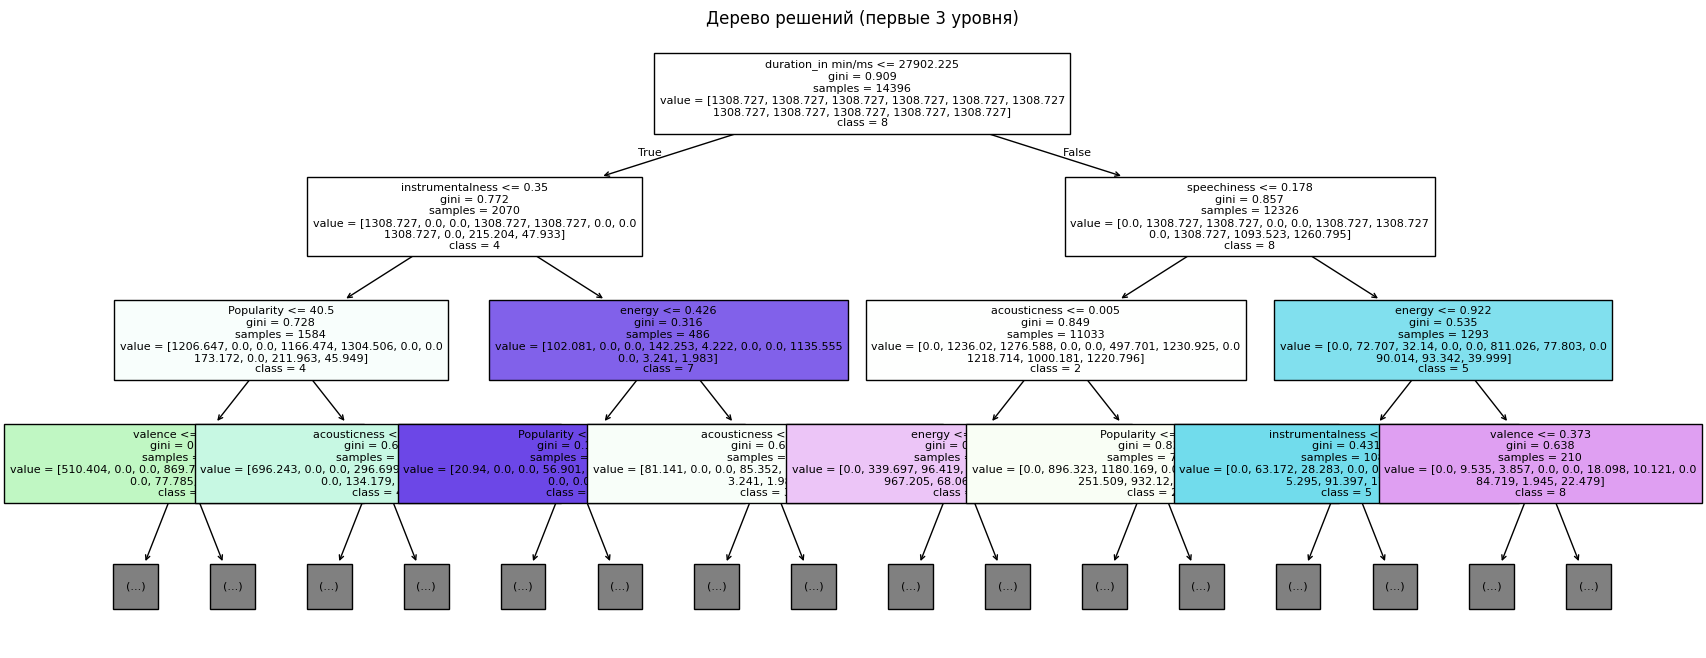

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    dt_best,
    max_depth=3,  # показываем только верхние 3 уровня
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,  # цветная заливка по классам
    fontsize=8,
)
plt.title("Дерево решений (первые 3 уровня)")
plt.show()

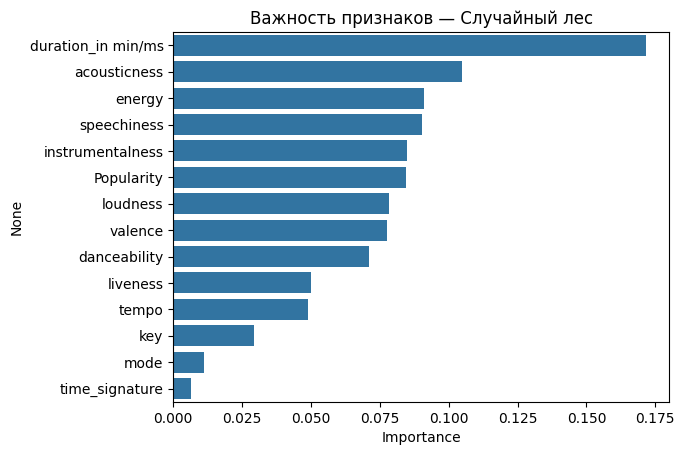

In [ ]:
# берём лучшую модель из поиска
best_rf_model = search.best_estimator_

importances = pd.Series(
    best_rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

sns.barplot(x=importances.values, y=importances.index)
plt.title("Важность признаков — Случайный лес")
plt.xlabel("Importance")
plt.show()